# Accounting review — styled version

This notebook uses the **same panel data and flag logic** as the original notebook, but:
- applies a cleaner visual theme
- annotates bar heights directly on the bars
- adds totals below each bar chart
- saves plot-ready tables to `plot_exports/` so plots can be regenerated later without rebuilding everything


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
DATA_DIR = Path("../prof_components_extracted")

MIN_YEAR = 2005
MAX_YEAR = 2024

# Revenue filter
MIN_REVENUE = 1.0

# Flagging thresholds for cost_ratio = (COGS + XSGA_COMPONENTS) / REVT
LOW_THRESHOLD = 0.40
HIGH_THRESHOLD = 1.20

# Optional: extreme thresholds for quick diagnostics
EXTREME_LOW_THRESHOLD = 0.15
EXTREME_HIGH_THRESHOLD = 2.00

# Plot settings
TOP_N_EXCHANGES = 15
TOP_N_SECTORS = 15

In [2]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

PLOT_EXPORT_DIR = Path("plot_exports")
PLOT_EXPORT_DIR.mkdir(exist_ok=True)

THEME = {
    "figure.facecolor": "#f5f5f7",
    "axes.facecolor": "#ebedf2",
    "axes.edgecolor": "#c9ced8",
    "axes.labelcolor": "#2f3b4a",
    "axes.titlecolor": "#1f2937",
    "axes.grid": True,
    "grid.color": "#b8c0cc",
    "grid.linestyle": "--",
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.color": "#435165",
    "ytick.color": "#435165",
    "legend.frameon": False,
    "figure.autolayout": False,
}

PALETTE = {
    "blue": "#4C78A8",
    "teal": "#54A6A6",
    "green": "#72B7B2",
    "orange": "#F2A65A",
    "red": "#D95F5F",
    "gold": "#E9C46A",
    "navy": "#2A4E6E",
    "slate": "#7B8BA3",
}

def apply_plot_theme():
    plt.rcParams.update(THEME)
    if HAS_SEABORN:
        sns.set_theme(style="darkgrid", rc=THEME)

def fmt_int(x, pos=None):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

def add_bar_labels(ax, fmt="{:,.0f}", pad_frac=0.01):
    ymax = max([p.get_height() for p in ax.patches], default=0)
    offset = ymax * pad_frac if ymax > 0 else 0.1
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + offset,
            fmt.format(value),
            ha="center",
            va="bottom",
            fontsize=10,
            color="#253243",
            fontweight="semibold",
        )

def add_total_text(ax, total, label="Total"):
    ax.text(
        0.995,
        -0.18,
        f"{label}: {total:,.0f}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
        color="#4b5563",
    )

def style_axis(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, pad=12)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_int))

def save_plot_data(name, df):
    out = PLOT_EXPORT_DIR / f"{name}.parquet"
    df.to_parquet(out, index=False)
    return out

def plot_annotated_bar(series, title, xlabel, ylabel, color, top_n=None, rotation=0):
    s = series.copy()
    if top_n is not None:
        s = s.head(top_n)
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(s.index.astype(str), s.values, color=color, edgecolor="white", linewidth=1.2)
    add_bar_labels(ax)
    add_total_text(ax, float(s.sum()))
    style_axis(ax, title=title, xlabel=xlabel, ylabel=ylabel)
    ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")
    fig.tight_layout()
    plt.show()
    return fig, ax

def plot_ratio_distribution(series, low_threshold, high_threshold, extreme_low, extreme_high):
    data = series.dropna().clip(lower=0, upper=3)
    fig, ax = plt.subplots(figsize=(11, 5))
    if HAS_SEABORN:
        sns.histplot(data, bins=60, kde=True, color=PALETTE["blue"], edgecolor="white", alpha=0.90, ax=ax)
    else:
        ax.hist(data, bins=60, color=PALETTE["blue"], edgecolor="white", alpha=0.90)
    for value, color, label in [
        (low_threshold, PALETTE["red"], "Low threshold"),
        (high_threshold, PALETTE["orange"], "High threshold"),
        (extreme_low, PALETTE["navy"], "Extreme low"),
        (extreme_high, PALETTE["teal"], "Extreme high"),
    ]:
        ax.axvline(value, linestyle="--", linewidth=2, color=color, label=f"{label}: {value:.2f}")
    style_axis(
        ax,
        title="Distribution of cost ratio",
        xlabel="(COGS + XSGA_COMPONENTS) / REVT   [clipped to 0–3 for display]",
        ylabel="Number of observations",
    )
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()
    return fig, ax

def display_summary_table(flag_summary):
    styled = (
        flag_summary.style
        .hide(axis="index")
        .format({"value": "{:,.0f}"})
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#d9dee7"), ("color", "#1f2937"), ("font-weight", "bold")]},
            {"selector": "td", "props": [("padding", "6px 10px")]},
            {"selector": "table", "props": [("border-collapse", "collapse"), ("font-family", "DejaVu Sans")]},
        ])
    )
    display(styled)

apply_plot_theme()


In [3]:
rows = []
bad_files = []

for fp in sorted(DATA_DIR.glob("*.csv")):
    try:
        df = pd.read_csv(fp)
    except Exception as e:
        bad_files.append((fp.name, f"read_error: {e}"))
        continue

    if "Year" not in df.columns:
        bad_files.append((fp.name, "missing Year"))
        continue

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"]).copy()
    df["Year"] = df["Year"].astype(int)
    df = df[(df["Year"] >= MIN_YEAR) & (df["Year"] <= MAX_YEAR)].copy()

    if df.empty:
        continue

    # fallback identifiers
    if "Ticker" not in df.columns:
        df["Ticker"] = fp.stem
    if "firm" not in df.columns:
        df["firm"] = fp.stem

    rows.append(df)

if not rows:
    raise ValueError("No valid CSV files were loaded.")

panel = pd.concat(rows, ignore_index=True)

print(f"Loaded rows: {len(panel):,}")
print(f"Unique tickers: {panel['Ticker'].nunique():,}")

if bad_files:
    print("\nSkipped files:")
    for name, reason in bad_files[:20]:
        print(f"- {name}: {reason}")

Loaded rows: 9,774
Unique tickers: 635


In [4]:
required_cols = ["REVT", "COGS", "XSGA_COMPONENTS"]
missing_required = [c for c in required_cols if c not in panel.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

for col in required_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["COGS_filled"] = panel["COGS"].fillna(0.0)
panel["XSGA_filled"] = panel["XSGA_COMPONENTS"].fillna(0.0)

panel["REVT_valid"] = panel["REVT"].notna() & (panel["REVT"] > MIN_REVENUE)
panel["TOTAL_COST_PROXY"] = panel["COGS_filled"] + panel["XSGA_filled"]

panel["cost_ratio"] = np.where(
    panel["REVT_valid"],
    panel["TOTAL_COST_PROXY"] / panel["REVT"],
    np.nan
)

# Diagnostics
panel["flag_low"] = panel["cost_ratio"] < LOW_THRESHOLD
panel["flag_high"] = panel["cost_ratio"] > HIGH_THRESHOLD
panel["flag_extreme_low"] = panel["cost_ratio"] < EXTREME_LOW_THRESHOLD
panel["flag_extreme_high"] = panel["cost_ratio"] > EXTREME_HIGH_THRESHOLD

panel["flag_any"] = panel["REVT_valid"] & (panel["flag_low"] | panel["flag_high"])

In [5]:

summary = panel[["cost_ratio"]].describe()

n_total = len(panel)
n_valid = int(panel["REVT_valid"].sum())
n_flagged = int(panel["flag_any"].sum())
n_low = int(panel["flag_low"].sum())
n_high = int(panel["flag_high"].sum())
n_unique_firms_total = panel["Ticker"].nunique()
n_unique_firms_valid = panel.loc[panel["REVT_valid"], "Ticker"].nunique()
n_unique_firms_flagged = panel.loc[panel["flag_any"], "Ticker"].nunique()

print(summary)
print("\nThresholds used:")
print(f"LOW_THRESHOLD          = {LOW_THRESHOLD}")
print(f"HIGH_THRESHOLD         = {HIGH_THRESHOLD}")
print(f"EXTREME_LOW_THRESHOLD  = {EXTREME_LOW_THRESHOLD}")
print(f"EXTREME_HIGH_THRESHOLD = {EXTREME_HIGH_THRESHOLD}")
print(f"MIN_REVENUE            = {MIN_REVENUE}")

flag_summary = pd.DataFrame({
    "metric": [
        "Total rows",
        "Valid ratio rows",
        "Flagged rows",
        "Low flagged rows",
        "High flagged rows",
        "Unique firms total",
        "Unique firms valid",
        "Unique firms flagged",
    ],
    "value": [
        n_total,
        n_valid,
        n_flagged,
        n_low,
        n_high,
        n_unique_firms_total,
        n_unique_firms_valid,
        n_unique_firms_flagged,
    ]
})

print("\nKey counts:")
print(flag_summary.to_string(index=False))

if n_valid > 0:
    print(f"\nFlagged / valid rows        : {n_flagged / n_valid:.2%}")
    print(f"Low / valid rows            : {n_low / n_valid:.2%}")
    print(f"High / valid rows           : {n_high / n_valid:.2%}")
if n_unique_firms_valid > 0:
    print(f"Flagged firms / valid firms : {n_unique_firms_flagged / n_unique_firms_valid:.2%}")

display_summary_table(flag_summary)
save_plot_data("flag_summary", flag_summary)


        cost_ratio
count  9364.000000
mean      1.228041
std       3.762883
min       0.000000
25%       0.716646
50%       0.885352
75%       0.959361
max     107.758662

Thresholds used:
LOW_THRESHOLD          = 0.4
HIGH_THRESHOLD         = 1.2
EXTREME_LOW_THRESHOLD  = 0.15
EXTREME_HIGH_THRESHOLD = 2.0
MIN_REVENUE            = 1.0

Key counts:
              metric  value
          Total rows   9774
    Valid ratio rows   9364
        Flagged rows   2010
    Low flagged rows   1019
   High flagged rows    991
  Unique firms total    635
  Unique firms valid    627
Unique firms flagged    305

Flagged / valid rows        : 21.47%
Low / valid rows            : 10.88%
High / valid rows           : 10.58%
Flagged firms / valid firms : 48.64%


metric,value
Total rows,"9,774"
Valid ratio rows,"9,364"
Flagged rows,"2,010"
Low flagged rows,"1,019"
High flagged rows,991
Unique firms total,635
Unique firms valid,627
Unique firms flagged,305


PosixPath('plot_exports/flag_summary.parquet')

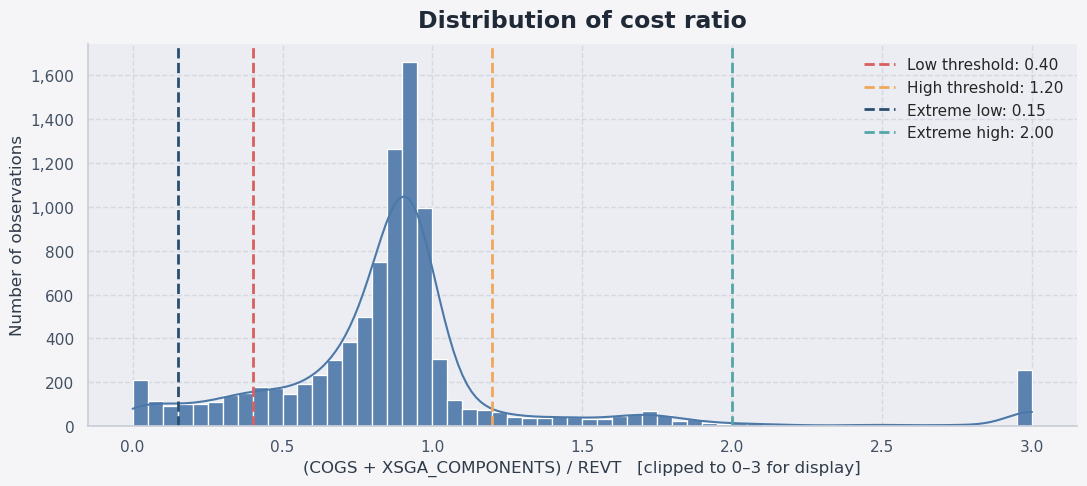

(<Figure size 1100x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of cost ratio'}, xlabel='(COGS + XSGA_COMPONENTS) / REVT   [clipped to 0–3 for display]', ylabel='Number of observations'>)

In [6]:

plot_ratio_distribution(
    panel["cost_ratio"],
    low_threshold=LOW_THRESHOLD,
    high_threshold=HIGH_THRESHOLD,
    extreme_low=EXTREME_LOW_THRESHOLD,
    extreme_high=EXTREME_HIGH_THRESHOLD,
)


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_68996/3510865542.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


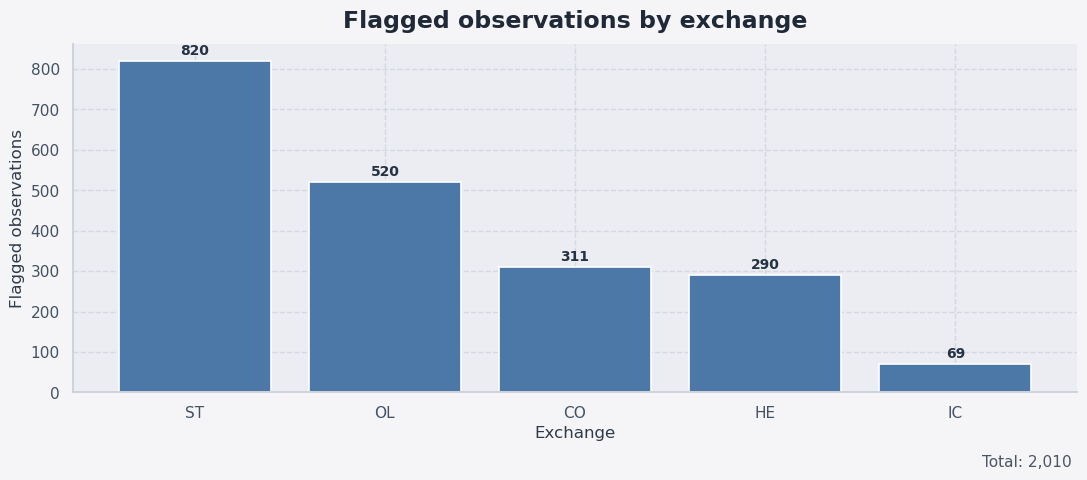

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_68996/3510865542.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


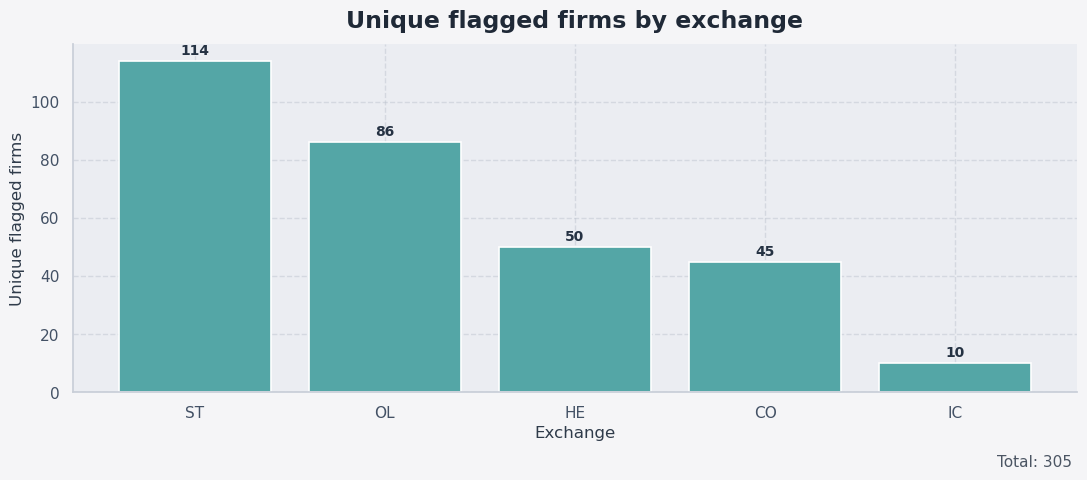

,Exchange,flagged_observations
0,ST,820
1,OL,520
2,CO,311
3,HE,290
4,IC,69


,Exchange,unique_flagged_firms
0,ST,114
1,OL,86
2,HE,50
3,CO,45
4,IC,10


PosixPath('plot_exports/exchange_unique_flagged_firms.parquet')

In [7]:

def extract_exchange(ticker):
    if pd.isna(ticker):
        return "Unknown"
    ticker = str(ticker)
    if "." in ticker:
        return ticker.split(".")[-1]
    return "Unknown"

panel["Exchange"] = panel["Ticker"].apply(extract_exchange)
flagged = panel.loc[panel["flag_any"]].copy()

exchange_obs = (
    flagged.groupby("Exchange")
    .size()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

exchange_firms = (
    flagged.groupby("Exchange")["Ticker"]
    .nunique()
    .sort_values(ascending=False)
    .head(TOP_N_EXCHANGES)
)

exchange_obs_df = exchange_obs.rename("flagged_observations").reset_index()
exchange_firms_df = exchange_firms.rename("unique_flagged_firms").reset_index()

plot_annotated_bar(
    exchange_obs,
    title="Flagged observations by exchange",
    xlabel="Exchange",
    ylabel="Flagged observations",
    color=PALETTE["blue"],
    top_n=TOP_N_EXCHANGES,
)
plot_annotated_bar(
    exchange_firms,
    title="Unique flagged firms by exchange",
    xlabel="Exchange",
    ylabel="Unique flagged firms",
    color=PALETTE["teal"],
    top_n=TOP_N_EXCHANGES,
)

display(exchange_obs_df)
display(exchange_firms_df)

save_plot_data("exchange_flagged_observations", exchange_obs_df)
save_plot_data("exchange_unique_flagged_firms", exchange_firms_df)


/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_68996/3510865542.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


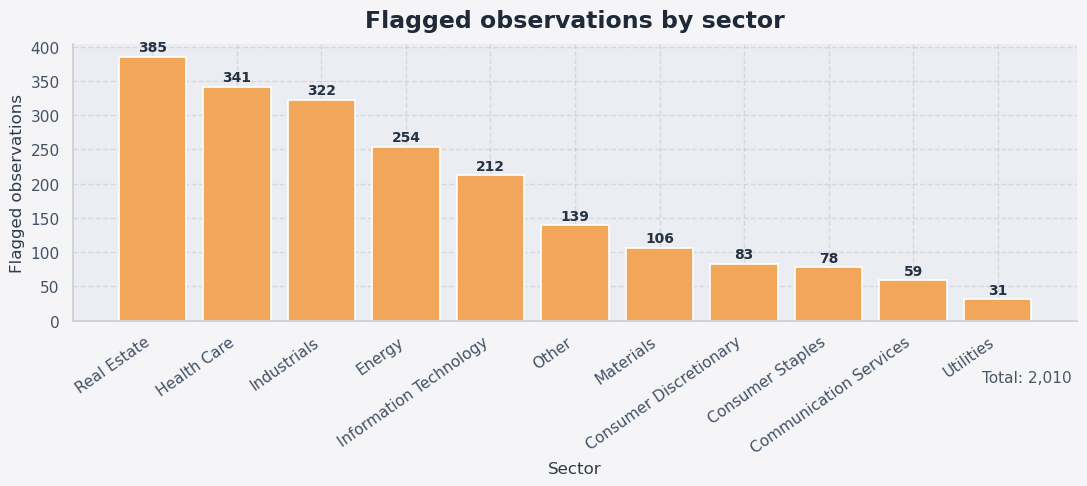

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_68996/3510865542.py:112: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(s.index.astype(str), rotation=rotation, ha="right" if rotation else "center")


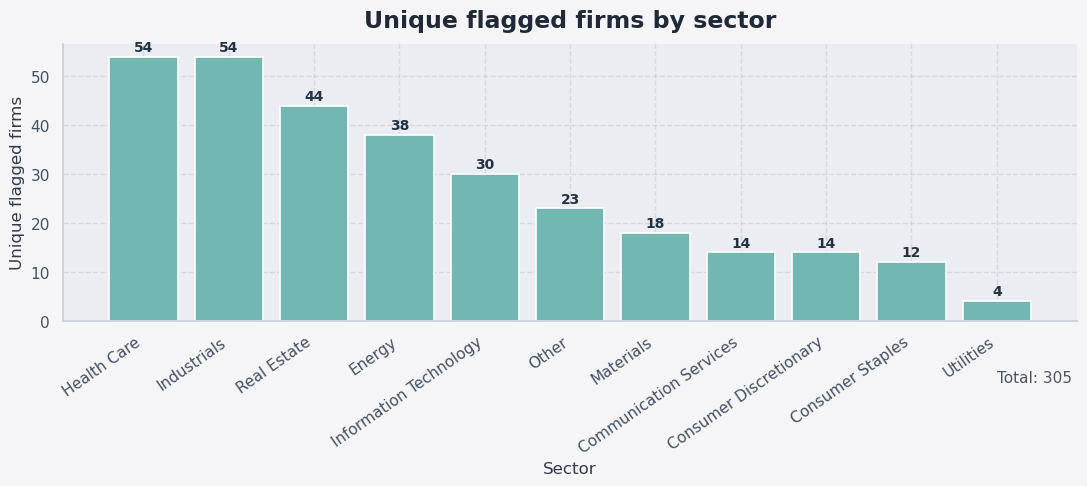

,Sector,flagged_observations
0,Real Estate,385
1,Health Care,341
2,Industrials,322
3,Energy,254
4,Information Technology,212
5,Other,139
6,Materials,106
7,Consumer Discretionary,83
8,Consumer Staples,78
9,Communication Services,59


,Sector,unique_flagged_firms
0,Health Care,54
1,Industrials,54
2,Real Estate,44
3,Energy,38
4,Information Technology,30
5,Other,23
6,Materials,18
7,Communication Services,14
8,Consumer Discretionary,14
9,Consumer Staples,12


In [8]:

if "Sector" in flagged.columns:
    sector_obs = (
        flagged.groupby("Sector")
        .size()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    sector_firms = (
        flagged.groupby("Sector")["Ticker"]
        .nunique()
        .sort_values(ascending=False)
        .head(TOP_N_SECTORS)
    )

    sector_obs_df = sector_obs.rename("flagged_observations").reset_index()
    sector_firms_df = sector_firms.rename("unique_flagged_firms").reset_index()

    plot_annotated_bar(
        sector_obs,
        title="Flagged observations by sector",
        xlabel="Sector",
        ylabel="Flagged observations",
        color=PALETTE["orange"],
        top_n=TOP_N_SECTORS,
        rotation=35,
    )
    plot_annotated_bar(
        sector_firms,
        title="Unique flagged firms by sector",
        xlabel="Sector",
        ylabel="Unique flagged firms",
        color=PALETTE["green"],
        top_n=TOP_N_SECTORS,
        rotation=35,
    )

    display(sector_obs_df)
    display(sector_firms_df)

    save_plot_data("sector_flagged_observations", sector_obs_df)
    save_plot_data("sector_unique_flagged_firms", sector_firms_df)
else:
    print("Column 'Sector' not found in panel.")


In [9]:

def classify_flag(row):
    if row["flag_low"] and row["flag_high"]:
        return "Both"
    if row["flag_low"]:
        return "Low"
    if row["flag_high"]:
        return "High"
    return "Not flagged"

flagged = panel.loc[panel["flag_any"]].copy()
flagged["flag_type"] = flagged.apply(classify_flag, axis=1)

show_cols = [
    "Ticker",
    "CompanyName",
    "Year",
    "Exchange",
    "Industry",
    "Sector",
    "REVT",
    "COGS",
    "XSGA_COMPONENTS",
    "TOTAL_COST_PROXY",
    "cost_ratio",
    "flag_type",
]
show_cols = [c for c in show_cols if c in flagged.columns]

flagged_table = (
    flagged[show_cols]
    .sort_values(["flag_type", "cost_ratio", "Ticker", "Year"], ascending=[True, True, True, True])
    .reset_index(drop=True)
)

print(f"Flagged rows: {len(flagged_table):,}")
display(flagged_table)

save_plot_data("flagged_table", flagged_table)


Flagged rows: 2,010


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
1,DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
2,EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
3,SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
4,DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High
...,...,...,...,...,...,...,...,...,...,...,...,...
2005,STWK.ST,Stockwik Forvaltning AB,2012,ST,Professional & Commercial Services,Industrials,129.27,0.00,51.61,51.61,0.399242,Low
2006,TEL.OL,Telenor ASA,2005,OL,Telecommunications Services,Communication Services,66566.00,16432.00,10145.00,26577.00,0.399258,Low
2007,NAVA.OL,Navamedic ASA,2012,OL,Pharmaceuticals,Health Care,88.68,0.00,35.41,35.41,0.399301,Low
2008,WALLb.ST,Wallenstam AB,2014,ST,Real Estate Operations,Real Estate,1438.50,403.26,171.77,575.03,0.399743,Low


PosixPath('plot_exports/flagged_table.parquet')

In [10]:

low_flagged = flagged_table.loc[flagged_table["flag_type"] == "Low"].reset_index(drop=True)
high_flagged = flagged_table.loc[flagged_table["flag_type"] == "High"].reset_index(drop=True)

print(f"Low flagged rows : {len(low_flagged):,}")
print(f"High flagged rows: {len(high_flagged):,}")

display(low_flagged.head(50))
display(high_flagged.head(50))

save_plot_data("low_flagged", low_flagged)
save_plot_data("high_flagged", high_flagged)


Low flagged rows : 1,019
High flagged rows: 991


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,AFAGR.HE,Afarak Group SE,2005,HE,Metals & Mining,Materials,736.35,0.0,0.0,0.0,0.0,Low
1,AKAST.OL,Akastor ASA,2012,OL,Oil & Gas Related Equipment and Services,Energy,41632.00,0.0,0.0,0.0,0.0,Low
2,AKAST.OL,Akastor ASA,2013,OL,Oil & Gas Related Equipment and Services,Energy,18448.00,0.0,0.0,0.0,0.0,Low
3,AKAST.OL,Akastor ASA,2014,OL,Oil & Gas Related Equipment and Services,Energy,21432.00,0.0,0.0,0.0,0.0,Low
4,AKAST.OL,Akastor ASA,2015,OL,Oil & Gas Related Equipment and Services,Energy,9983.00,0.0,0.0,0.0,0.0,Low
5,AKAST.OL,Akastor ASA,2016,OL,Oil & Gas Related Equipment and Services,Energy,4975.00,0.0,0.0,0.0,0.0,Low
6,AKBM.OL,Aker Biomarine ASA,2015,OL,Food & Tobacco,Consumer Staples,831.93,0.0,0.0,0.0,0.0,Low
7,AKBM.OL,Aker Biomarine ASA,2016,OL,Food & Tobacco,Consumer Staples,967.14,0.0,0.0,0.0,0.0,Low
8,AKBM.OL,Aker Biomarine ASA,2017,OL,Food & Tobacco,Consumer Staples,1026.22,0.0,0.0,0.0,0.0,Low
9,APETIT.HE,Apetit Oyj,2006,HE,Food & Tobacco,Consumer Staples,1982.83,0.0,0.0,0.0,0.0,Low


,Ticker,CompanyName,Year,Exchange,Industry,Sector,REVT,COGS,XSGA_COMPONENTS,TOTAL_COST_PROXY,cost_ratio,flag_type
0,NRC.OL,NRC Group ASA,2011,OL,Construction & Engineering,Industrials,288.63,100.15,246.28,346.43,1.200256,High
1,DOV1V.HE,Dovre Group Oyj,2024,HE,Professional & Commercial Services,Industrials,1154.26,1217.77,167.71,1385.48,1.200319,High
2,EMGS.OL,Electromagnetic Geoservices ASA,2008,OL,Oil & Gas Related Equipment and Services,Energy,655.97,398.16,389.78,787.94,1.201183,High
3,SOBIV.ST,Swedish Orphan Biovitrum AB (publ),2011,ST,Pharmaceuticals,Health Care,1650.38,808.65,1174.78,1983.43,1.201802,High
4,DIGIGR.HE,Digitalist Group Oyj,2018,HE,Software & IT Services,Information Technology,237.51,21.83,263.67,285.50,1.202055,High
5,ROVS.CO,Rovsing A/S,2012,CO,Software & IT Services,Information Technology,18.79,7.38,15.22,22.60,1.202767,High
6,DIGIGR.HE,Digitalist Group Oyj,2017,HE,Software & IT Services,Information Technology,186.60,22.10,202.48,224.58,1.203537,High
7,BIOGb.ST,Biogaia AB,2008,ST,Pharmaceuticals,Health Care,124.18,41.26,108.33,149.59,1.204622,High
8,AKH.OL,Aker Horizons ASA,2024,OL,Electric Utilities & IPPs,Utilities,2537.00,1228.00,1829.00,3057.00,1.204966,High
9,EMGS.OL,Electromagnetic Geoservices ASA,2016,OL,Oil & Gas Related Equipment and Services,Energy,373.86,152.61,297.90,450.51,1.205023,High


PosixPath('plot_exports/high_flagged.parquet')